# DATA ACQUISITION

In [4]:
!kaggle datasets download -d surajghuwalewala/ham1000-segmentation-and-classification

Dataset URL: https://www.kaggle.com/datasets/surajghuwalewala/ham1000-segmentation-and-classification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100%|██████████████████████████████████████▉| 2.59G/2.59G [00:18<00:00, 163MB/s]
100%|███████████████████████████████████████| 2.59G/2.59G [00:18<00:00, 148MB/s]


In [5]:
import zipfile

# Unzip the dataset
with zipfile.ZipFile('ham1000-segmentation-and-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('ham10000_data')

In [6]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
# Path to the extracted dataset
data_path = 'ham10000_data/'

# Load GroundTruth.csv
df = pd.read_csv(os.path.join(data_path, 'GroundTruth.csv'))

# Display the first few rows
print(df.head())

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0


# DATA MANIPULATION

In [8]:
# Path to the images folder
image_folder = os.path.join(data_path, 'images')  # Ensure the correct path

# Preprocessing function: grayscale conversion, resizing, normalization
def preprocess_image(image_path, img_size=(128, 128)):
    img = cv2.imread(image_path)  # Read the image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    img = cv2.resize(img, img_size)  # Resize image
    img = img / 255.0  # Normalize pixel values to [0, 1]
    return img

# Filter rows where the MEL column is 1 (melanoma images)
melanoma_df = df[df['MEL'] == 1]

# Preprocess and store melanoma images
melanoma_images = []
for img_file in melanoma_df['image']:
    img_path = os.path.join(image_folder, img_file + '.jpg')  # Adjust extension if necessary
    melanoma_images.append(preprocess_image(img_path))

# Convert to numpy array
melanoma_images = np.array(melanoma_images)
print(f"Shape of melanoma images: {melanoma_images.shape}")


Shape of melanoma images: (1113, 128, 128)


# GAN

In [9]:
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.callbacks import Callback
import os
from tensorflow.keras.preprocessing.image import array_to_img

# Define the Generator model
class Generator(Model):
    def __init__(self):
        super(Generator, self).__init__()
        self.dense = layers.Dense(131072, activation='relu')  # 128*128*1
        self.reshape = layers.Reshape((32, 32, 128))  # Adjust as necessary
        self.conv1 = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')
        self.conv2 = layers.Conv2DTranspose(1, (3, 3), strides=2, padding='same', activation='sigmoid')  # Final output

    def call(self, inputs):
        x = self.dense(inputs)
        x = self.reshape(x)
        x = self.conv1(x)
        x = self.conv2(x)  # Final layer for 128x128
        return x

# Define the Discriminator model
class Discriminator(Model):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv1 = layers.Conv2D(64, (3, 3), strides=2, padding='same', activation='relu')
        self.conv2 = layers.Conv2D(128, (3, 3), strides=2, padding='same', activation='relu')
        self.flatten = layers.Flatten()
        self.dense = layers.Dense(1, activation='sigmoid')  # Expecting output from flatten

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.conv2(x)
        x = self.flatten(x)
        return self.dense(x)

# Instantiate the models
generator = Generator()
discriminator = Discriminator()

# Define the MelanomaGAN class
class MelanomaGAN(Model):
    def __init__(self, generator, discriminator, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.generator = generator
        self.discriminator = discriminator

    def compile(self, g_opt, d_opt, g_loss, d_loss, *args, **kwargs):
        super().compile(*args, **kwargs)
        self.g_opt = g_opt
        self.d_opt = d_opt
        self.g_loss = g_loss
        self.d_loss = d_loss

    def train_step(self, batch):
        real_images = batch
        batch_size = tf.shape(batch)[0]
        noise = tf.random.normal([batch_size, 128])

        # Generate fake images using the generator
        fake_images = self.generator(noise)

        # Train the discriminator
        with tf.GradientTape() as d_tape:
            real_output = self.discriminator(real_images)
            fake_output = self.discriminator(fake_images)
            d_loss_real = self.d_loss(tf.ones_like(real_output), real_output)
            d_loss_fake = self.d_loss(tf.zeros_like(fake_output), fake_output)
            d_loss = (d_loss_real + d_loss_fake) / 2

        # Apply gradients for the discriminator
        d_gradients = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_opt.apply_gradients(zip(d_gradients, self.discriminator.trainable_variables))

        # Train the generator
        with tf.GradientTape() as g_tape:
            generated_images = self.generator(noise)
            fake_output = self.discriminator(generated_images)
            g_loss = self.g_loss(tf.ones_like(fake_output), fake_output)

        # Apply gradients for the generator
        g_gradients = g_tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_opt.apply_gradients(zip(g_gradients, self.generator.trainable_variables))

        return {"d_loss": d_loss, "g_loss": g_loss}

# Instantiate the MelanomaGAN class
melanoma_gan = MelanomaGAN(generator, discriminator)

# Compile the model
g_opt = tf.keras.optimizers.Adam(1e-4)
d_opt = tf.keras.optimizers.Adam(1e-5)
g_loss = tf.keras.losses.BinaryCrossentropy()
d_loss = tf.keras.losses.BinaryCrossentropy()
melanoma_gan.compile(g_opt, d_opt, g_loss, d_loss)

# Define the custom callback for monitoring
class MelanomaModelMonitor(Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim
        # Create the directory if it doesn't exist
        os.makedirs('generated_melanoma_images', exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal((self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images *= 255
        generated_images = tf.clip_by_value(generated_images, 0, 255)  # Ensure values are in the right range
        generated_images = generated_images.numpy()
        for i in range(self.num_img):
            img = array_to_img(generated_images[i])
            img.save(os.path.join('generated_melanoma_images', f'melanoma_generated_img_{epoch}_{i}.png'))

# Create the melanoma dataset and apply batching
BATCH_SIZE = 128
# Assuming melanoma_images is your dataset, reshape it as needed
melanoma_images = melanoma_images.reshape(-1, 128, 128, 1)  # Adjust for grayscale images
melanoma_dataset = tf.data.Dataset.from_tensor_slices(melanoma_images).batch(BATCH_SIZE)

# Train the model with the melanoma dataset
hist = melanoma_gan.fit(melanoma_dataset, epochs=1000, callbacks=[MelanomaModelMonitor()])


Epoch 1/1000


I0000 00:00:1730275616.917233     112 service.cc:145] XLA service 0x7e90380094b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1730275616.917306     112 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1730275616.917312     112 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


1/9 ━━━━━━━━━━━━━━━━━━━━ 1:12 9s/step - d_loss: 0.6939 - g_loss: 0.6924

I0000 00:00:1730275623.296473     112 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 755ms/step - d_loss: 0.6881 - g_loss: 0.6439
Epoch 2/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - d_loss: 0.6817 - g_loss: 0.6047
Epoch 3/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - d_loss: 0.6762 - g_loss: 0.6222
Epoch 4/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - d_loss: 0.6709 - g_loss: 0.6419
Epoch 5/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - d_loss: 0.6656 - g_loss: 0.6432
Epoch 6/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - d_loss: 0.6601 - g_loss: 0.6468
Epoch 7/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - d_loss: 0.6548 - g_loss: 0.6580
Epoch 8/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - d_loss: 0.6500 - g_loss: 0.6653
Epoch 9/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - d_loss: 0.6457 - g_loss: 0.6702
Epoch 10/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - d_loss: 0.6435 - g_loss: 0.6762
Epoch 11/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - d_loss: 0.6427 - g_loss: 0.6795
Epoch 12/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - d_loss: 0

# GENERATOR AND DISCRIMINATOR LOSSES

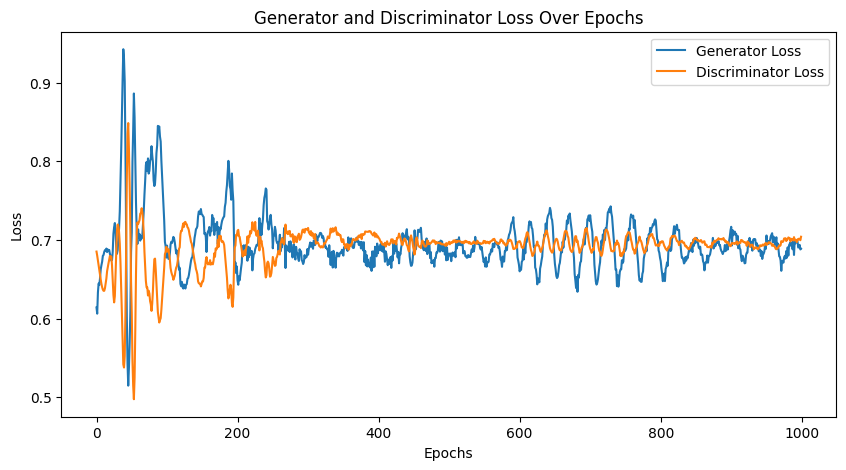

In [10]:
def plot_losses(g_loss, d_loss):
    plt.figure(figsize=(10, 5))
    plt.plot(g_loss, label='Generator Loss')
    plt.plot(d_loss, label='Discriminator Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Generator and Discriminator Loss Over Epochs')
    plt.legend()
    plt.show()
plot_losses(hist.history['g_loss'], hist.history['d_loss'])

# IMAGE GENERATION

In [11]:
imgs = generator.predict(tf.random.normal((7000, 128)))

219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


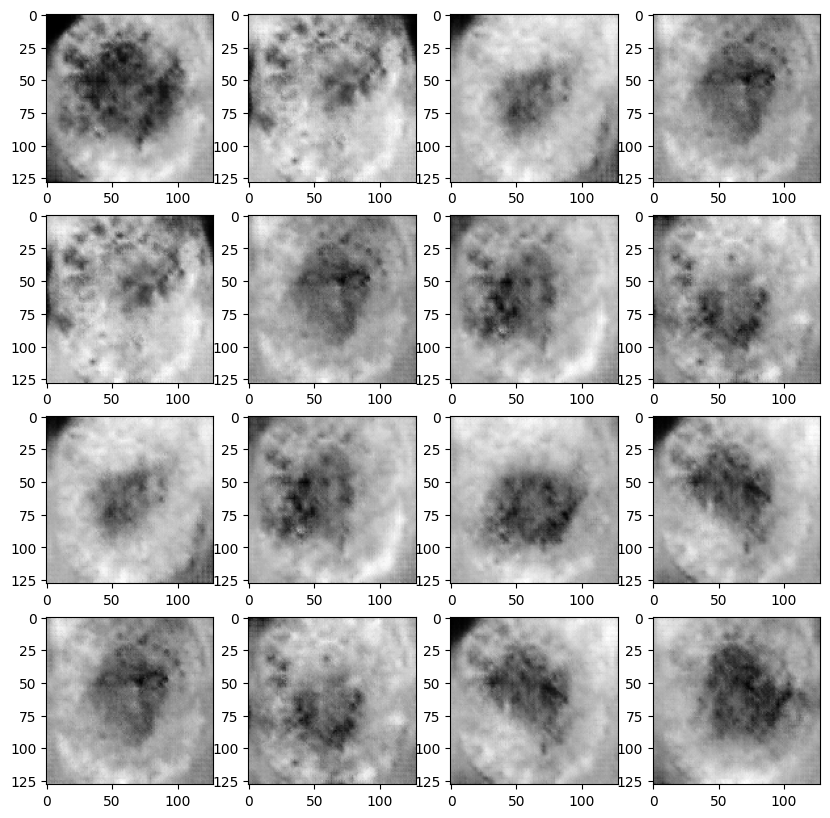

In [12]:
fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(10,10))
for r in range(4):
    for c in range(4):
        ax[r][c].imshow(imgs[(r+1)*(c+1)-1], cmap='gray')

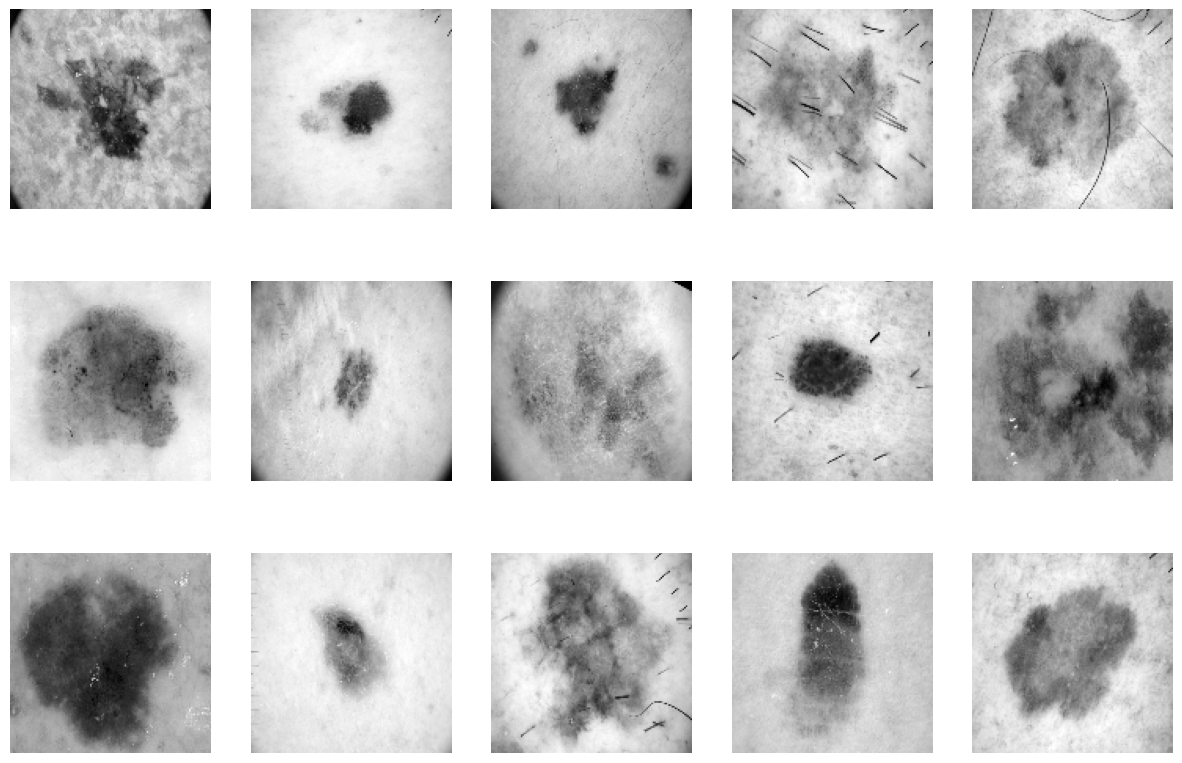

In [13]:
import matplotlib.pyplot as plt

def display_images(images, num_images=15, img_size=(128, 128)):
    plt.figure(figsize=(15, 10))  # Set the figure size
    for i in range(num_images):
        plt.subplot(3, 5, i + 1)  # Create a subplot with 3 rows and 5 columns
        plt.imshow(images[i], cmap='gray')  # Display image in grayscale
        plt.axis('off')  # Turn off axis labels
    plt.show()

# Ensure that we have at least 15 images to display
num_images_to_display = min(15, len(melanoma_images))

# Call the function to display the images
display_images(melanoma_images, num_images=num_images_to_display)


In [14]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications import InceptionV3
from scipy.linalg import sqrtm

# Function to calculate the FID score
def calculate_fid(real_images, generated_images):
    # Load the InceptionV3 model pre-trained on ImageNet
    model = InceptionV3(include_top=False, pooling='avg', input_shape=(128, 128, 3))

    # Convert grayscale images to RGB by repeating the grayscale values across three channels
    real_images_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(real_images))
    generated_images_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(generated_images))

    # Resize images to match InceptionV3 input size
    real_images_resized = tf.image.resize(real_images_rgb, (128, 128))
    generated_images_resized = tf.image.resize(generated_images_rgb, (128, 128))

    # Get the feature maps (activations) from the model
    real_activations = model.predict(real_images_resized)
    fake_activations = model.predict(generated_images_resized)

    # Calculate mean and covariance of activations for real and generated images
    mu1, sigma1 = real_activations.mean(axis=0), np.cov(real_activations, rowvar=False)
    mu2, sigma2 = fake_activations.mean(axis=0), np.cov(fake_activations, rowvar=False)

    # Compute FID score
    diff = mu1 - mu2
    covmean = sqrtm(sigma1.dot(sigma2))

    # Handle numerical issues with sqrtm if complex numbers appear
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid_score = np.sum(diff**2) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid_score

# Path to the images folder (assuming paths are already set up)
# You already have melanoma_images and imgs loaded

# Call the FID calculation function
fid = calculate_fid(melanoma_images, imgs)
print(f"FID score: {fid}")


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 221ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step
FID score: 810.687891546504


# COMBINING DATASETS

In [15]:
# Step 1: Load and Preprocess NV Images
nv_df = df[df['NV'] == 1]

# Preprocess and store NV images
nv_images = []
for img_file in nv_df['image']:
    img_path = os.path.join(image_folder, img_file + '.jpg')
    nv_images.append(preprocess_image(img_path))

# Convert NV images to numpy array
nv_images = np.array(nv_images)
print(f"Shape of NV images: {nv_images.shape}")

# Reshape NV images to include a channel dimension
nv_images = nv_images.reshape(-1, 128, 128, 1)

# Step 2: Combine Original and Generated Images
# Reshape 'imgs' (generated images) to ensure consistency
generated_images = imgs.reshape(-1, 128, 128, 1)

# Create labels for the images
melanoma_labels = np.ones(len(melanoma_images))  # Label 1 for melanoma (malignant)
nv_labels = np.zeros(len(nv_images))  # Label 0 for NV (benign)
generated_labels = np.ones(len(generated_images))  # Label 1 for generated melanoma images

# Combine images and labels
combined_images = np.concatenate((melanoma_images, nv_images, generated_images), axis=0)
combined_labels = np.concatenate((melanoma_labels, nv_labels, generated_labels), axis=0)

print(f"Shape of combined images: {combined_images.shape}")
print(f"Shape of combined labels: {combined_labels.shape}")

Shape of NV images: (6705, 128, 128)
Shape of combined images: (14818, 128, 128, 1)
Shape of combined labels: (14818,)


# CNN

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.6199 - loss: 1.2275 - val_accuracy: 0.9224 - val_loss: 0.3654 - learning_rate: 0.0010
Epoch 2/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9238 - loss: 0.3391 - val_accuracy: 0.9211 - val_loss: 0.3285 - learning_rate: 0.0010
Epoch 3/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9250 - loss: 0.3131 - val_accuracy: 0.9241 - val_loss: 0.2958 - learning_rate: 0.0010
Epoch 4/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9262 - loss: 0.2936 - val_accuracy: 0.9207 - val_loss: 0.2979 - learning_rate: 0.0010
Epoch 5/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9201 - loss: 0.2995 - val_accuracy: 0.9261 - val_loss: 0.2744 - learning_rate: 0.0010
Epoch 6/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9275 - loss: 0.2789 - val_accuracy: 0.9194 - val_loss: 0.3015 - learning_rate: 0.0010
Epoch 7/30
371/371 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9295 - loss: 0

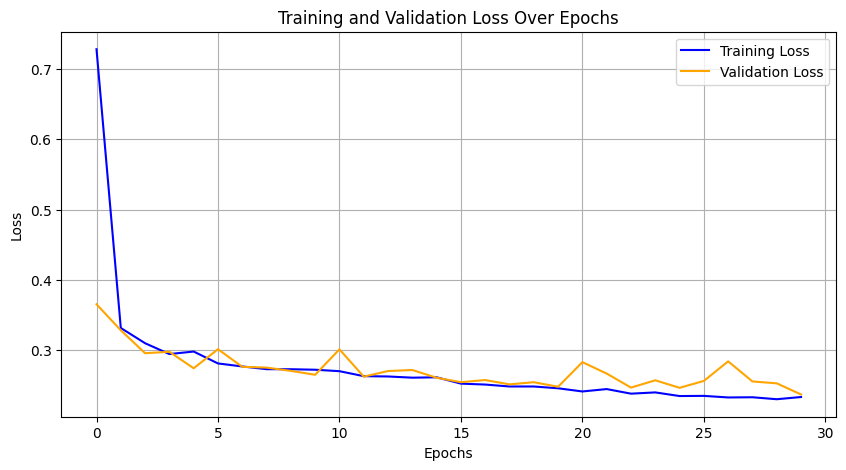

In [17]:
# Step 3: Split the Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    combined_images, combined_labels, test_size=0.2, random_state=42, stratify=combined_labels
)

# Expand dimensions for grayscale images to match CNN input
X_train = X_train.reshape(-1, 128, 128, 1)
X_test = X_test.reshape(-1, 128, 128, 1)

# Step 4: Create a CNN Model for Classification
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

def create_cnn_model(input_shape=(128, 128, 1)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.01), input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate and compile the model
cnn_model = create_cnn_model()

# Step 5: Train the Model with Early Stopping and Learning Rate Reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-4)  # Adjusted parameters

history = cnn_model.fit(
    X_train, y_train,
    epochs=30,  # Increased number of epochs
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],  # Add EarlyStopping and ReduceLROnPlateau callbacks
    verbose=1  # Verbose output
)

# Step 6: Evaluate the Model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

# Step 7: Plot Training and Validation Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.97      0.92      1341
         1.0       0.97      0.89      0.93      1623

    accuracy                           0.93      2964
   macro avg       0.93      0.93      0.93      2964
weighted avg       0.93      0.93      0.93      2964



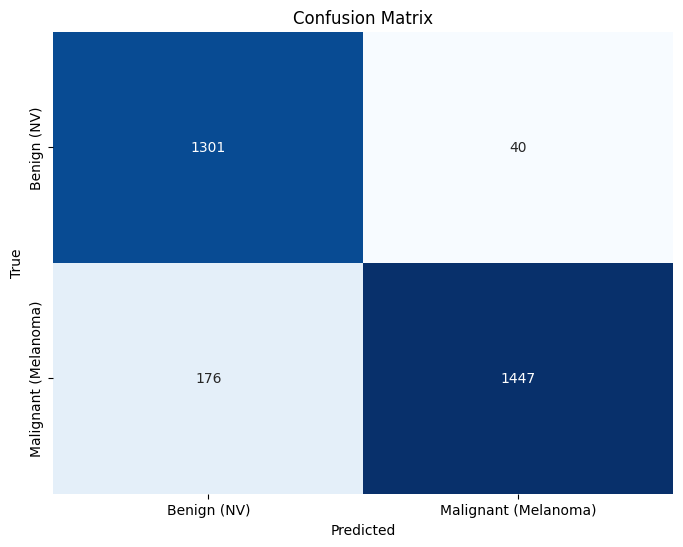

In [20]:
# Step 1: Make Predictions
y_pred = (cnn_model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary predictions

# Step 2: Generate Classification Report
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

# Step 3: Generate Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)

# Step 4: Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (NV)', 'Malignant (Melanoma)'],
            yticklabels=['Benign (NV)', 'Malignant (Melanoma)'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

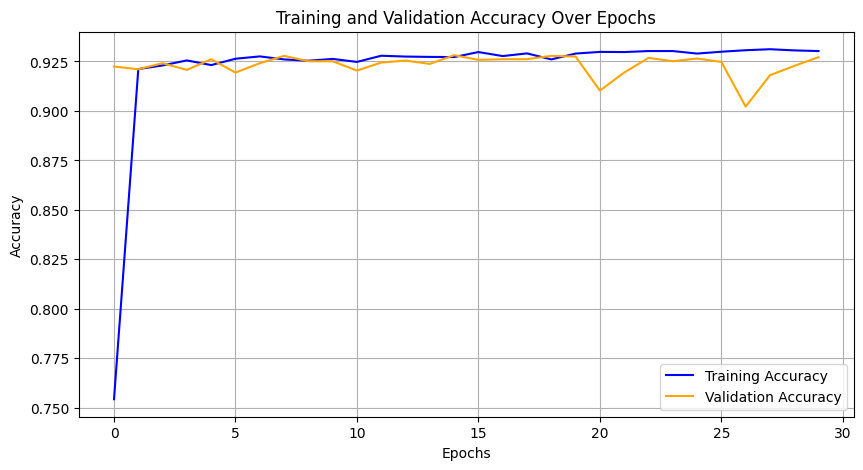

In [25]:
# Plotting training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [37]:
pip install keras-tuner


/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


# HYPERPARAMETER FINE TUNING

In [26]:
# Step 1: Import necessary libraries
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from kerastuner import RandomSearch

# Step 2: Split the Data
X_train, X_test, y_train, y_test = train_test_split(
    combined_images, combined_labels, test_size=0.2, random_state=42, stratify=combined_labels
)

# Expand dimensions for grayscale images to match CNN input
X_train = X_train.reshape(-1, 128, 128, 1)
X_test = X_test.reshape(-1, 128, 128, 1)

# Step 3: Define the Model Building Function
def build_model(hp):
    model = Sequential()
    model.add(Conv2D(hp.Int('conv1_filters', min_value=16, max_value=64, step=16), 
                     (3, 3), activation='relu', kernel_regularizer=l2(0.01), 
                     input_shape=(128, 128, 1)))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(hp.Int('conv2_filters', min_value=32, max_value=128, step=16), 
                     (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(hp.Int('conv3_filters', min_value=64, max_value=256, step=32), 
                     (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
    model.add(MaxPooling2D((2, 2)))
    
    model.add(Flatten())
    
    model.add(Dense(hp.Int('dense_units', min_value=64, max_value=256, step=32), activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.2))
    
    model.add(Dense(1, activation='sigmoid'))  # Binary classification
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Step 4: Initialize KerasTuner
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=25,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='skin_cancer_classification'
)

# Step 5: Set Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Step 6: Start Hyperparameter Tuning
tuner.search(X_train, y_train, 
             epochs=20, 
             batch_size=32,
             validation_data=(X_test, y_test),
             callbacks=[early_stopping, reduce_lr])

# Step 7: Get the Best Model and Hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(best_hyperparameters.values)

# Step 8: Evaluate the Best Model
loss, accuracy = best_model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

# Step 9: Make Predictions and Generate Classification Report
y_pred = (best_model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary predictions

from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)


Trial 25 Complete [00h 02m 18s]
val_accuracy: 0.9291498064994812

Best val_accuracy So Far: 0.9321862459182739
Total elapsed time: 01h 04m 38s


/opt/conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:415: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best Hyperparameters:
{'conv1_filters': 48, 'conv2_filters': 48, 'conv3_filters': 256, 'dense_units': 160}
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9324 - loss: 0.2357
Test Loss: 0.23874372243881226, Test Accuracy: 0.9321862459182739
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.98      0.93      1341
         1.0       0.98      0.89      0.94      1623

    accuracy                           0.93      2964
   macro avg       0.93      0.94      0.93      2964
weighted avg       0.94      0.93      0.93      2964



# TRAINING ONE WITH BEST PARAMETERS

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.5417 - loss: 1.5439 - val_accuracy: 0.6194 - val_loss: 0.7278 - learning_rate: 0.0010
Epoch 2/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8082 - loss: 0.5476 - val_accuracy: 0.9180 - val_loss: 0.3579 - learning_rate: 0.0010
Epoch 3/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9072 - loss: 0.3742 - val_accuracy: 0.9221 - val_loss: 0.3296 - learning_rate: 0.0010
Epoch 4/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9199 - loss: 0.3335 - val_accuracy: 0.9207 - val_loss: 0.3413 - learning_rate: 0.0010
Epoch 5/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9177 - loss: 0.3218 - val_accuracy: 0.9160 - val_loss: 0.3154 - learning_rate: 0.0010
Epoch 6/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9146 - loss: 0.3189 - val_accuracy: 0.9231 - val_loss: 0.2935 - learning_rate: 0.0010
Epoch 7/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9196 - loss: 0

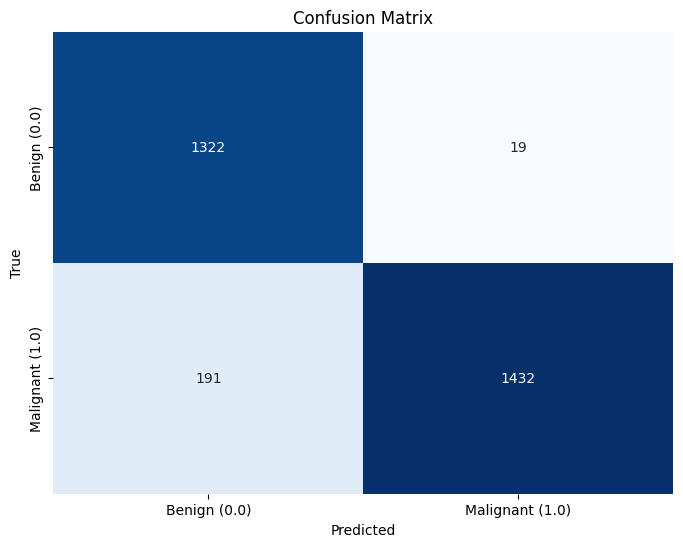

In [27]:
# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Step 2: Load and Prepare Data
# Assuming combined_images and combined_labels are already defined
X_train, X_test, y_train, y_test = train_test_split(
    combined_images, combined_labels, test_size=0.2, random_state=42, stratify=combined_labels
)

# Expand dimensions for grayscale images to match CNN input
X_train = X_train.reshape(-1, 128, 128, 1)
X_test = X_test.reshape(-1, 128, 128, 1)

# Step 3: Create a CNN Model for Classification with Best Hyperparameters
def create_cnn_model(input_shape=(128, 128, 1)):
    model = Sequential([
        Conv2D(48, (3, 3), activation='relu', kernel_regularizer=l2(0.01), input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(48, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
        MaxPooling2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(160, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate and compile the model
cnn_model = create_cnn_model()

# Step 4: Train the Model with Early Stopping and Learning Rate Reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

history = cnn_model.fit(
    X_train, y_train,
    epochs=50,  # Increase the number of epochs
    batch_size=64,  # Increased batch size
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr]  # Add EarlyStopping and ReduceLROnPlateau callbacks
)

# Step 5: Evaluate the Model
loss, accuracy = cnn_model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

# Step 6: Make Predictions and Generate Classification Report
y_pred = (cnn_model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary predictions

# Step 8: Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 9: Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0.0)', 'Malignant (1.0)'],
            yticklabels=['Benign (0.0)', 'Malignant (1.0)'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


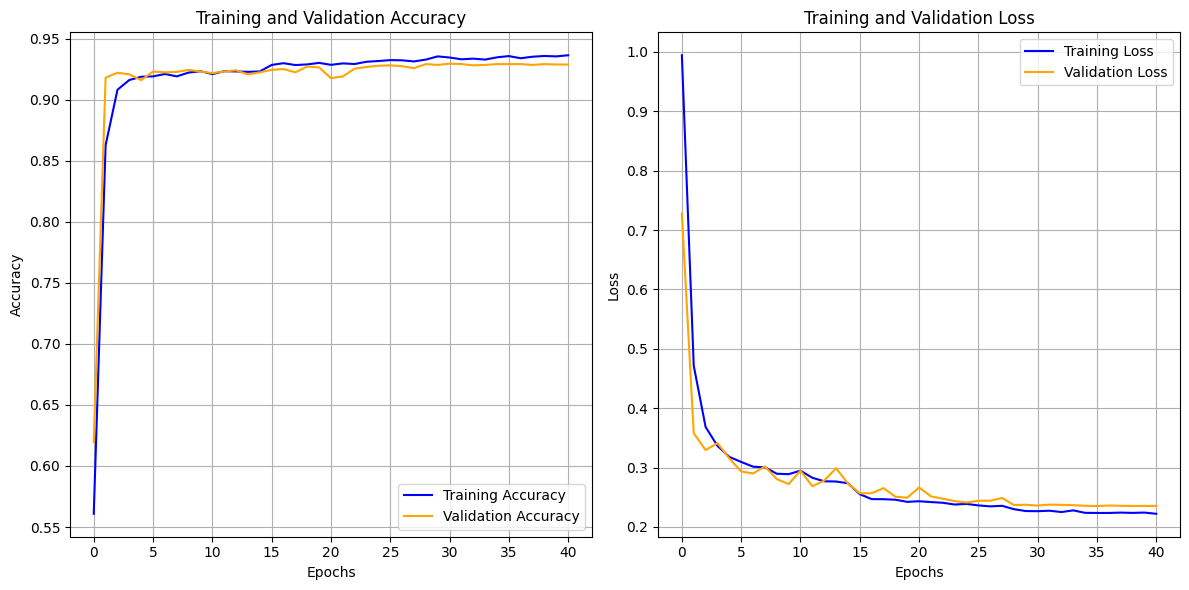

In [29]:
# Plotting training and validation accuracy
plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid()

plt.tight_layout()
plt.show()


In [30]:
from sklearn.metrics import classification_report

# Assuming y_test and y_pred are defined
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.99      0.93      1341
         1.0       0.99      0.88      0.93      1623

    accuracy                           0.93      2964
   macro avg       0.93      0.93      0.93      2964
weighted avg       0.94      0.93      0.93      2964



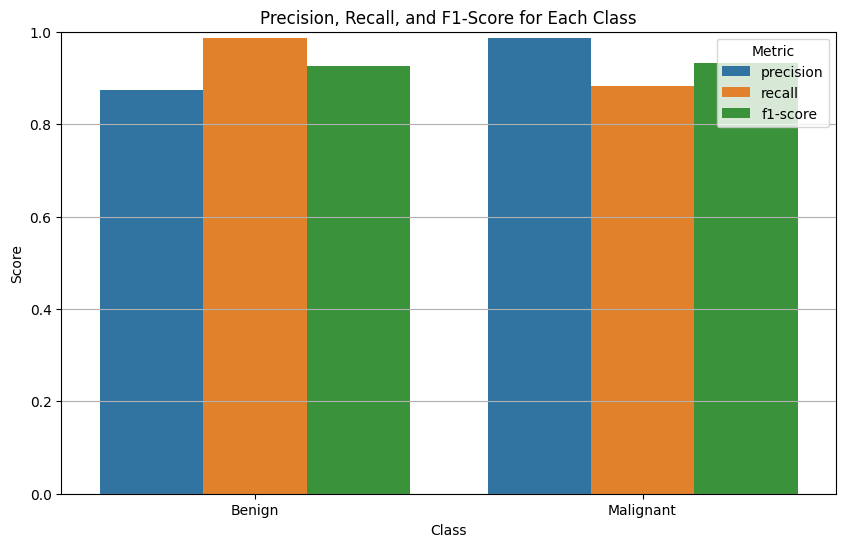

In [38]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report

# Get the classification report as a dictionary for easier plotting
report = classification_report(y_test, y_pred, output_dict=True)

# Extract precision, recall, and f1-score for each class
metrics = ['precision', 'recall', 'f1-score']
classes = ['Benign', 'Malignant']  # Adjust these if necessary based on your labels

# Create a DataFrame for easy plotting
data = {
    'Class': [],
    'Metric': [],
    'Value': []
}

for cls in classes:
    for metric in metrics:
        data['Class'].append(cls)
        data['Metric'].append(metric)
        if cls=='Benign':
            data['Value'].append(report['0.0'][metric])
        else:
            data['Value'].append(report['1.0'][metric])

# Convert the data dictionary into a DataFrame
import pandas as pd
df = pd.DataFrame(data)

# Plot the bar plot using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Value', hue='Metric', data=df)
plt.title('Precision, Recall, and F1-Score for Each Class')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()


Training on fold 1/5...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.5003 - loss: 1.9063 - val_accuracy: 0.4890 - val_loss: 0.9222 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5184 - loss: 0.8677 - val_accuracy: 0.4890 - val_loss: 0.7705 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5035 - loss: 0.7560 - val_accuracy: 0.4890 - val_loss: 0.7258 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5164 - loss: 0.7199 - val_accuracy: 0.4890 - val_loss: 0.7089 - learning_rate: 0.0010
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5118 - loss: 0.7060 - val_accuracy: 0.4890 - val_loss: 0.7016 - learning_rate: 0.0010
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5199 - loss: 0.6996 - val_accuracy: 0.4890 - val_loss: 0.6982 - learning_rate: 0.0010
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5299 

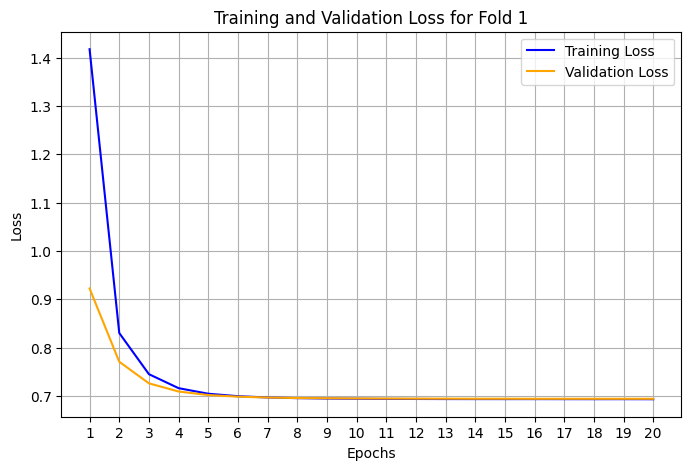

Training on fold 2/5...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.4941 - loss: 1.8289 - val_accuracy: 0.4750 - val_loss: 0.8720 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4905 - loss: 0.8255 - val_accuracy: 0.5250 - val_loss: 0.7471 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4912 - loss: 0.7369 - val_accuracy: 0.5250 - val_loss: 0.7152 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5011 - loss: 0.7117 - val_accuracy: 0.5250 - val_loss: 0.7035 - learning_rate: 0.0010
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4993 - loss: 0.7021 - val_accuracy: 0.5250 - val_loss: 0.6986 - learning_rate: 0.0010
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5029 - loss: 0.6980 - val_accuracy: 0.5250 - val_loss: 0.6962 - learning_rate: 0.0010
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4995 

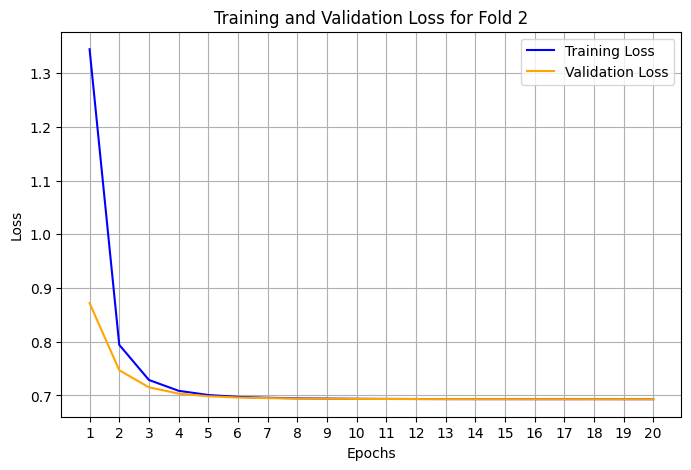

Training on fold 3/5...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.5050 - loss: 2.0060 - val_accuracy: 0.5110 - val_loss: 0.9915 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5076 - loss: 0.9330 - val_accuracy: 0.5110 - val_loss: 0.8236 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4796 - loss: 0.8053 - val_accuracy: 0.5110 - val_loss: 0.7636 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5061 - loss: 0.7550 - val_accuracy: 0.5110 - val_loss: 0.7341 - learning_rate: 0.0010
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4976 - loss: 0.7297 - val_accuracy: 0.5110 - val_loss: 0.7182 - learning_rate: 0.0010
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4949 - loss: 0.7158 - val_accuracy: 0.5110 - val_loss: 0.7090 - learning_rate: 0.0010
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5131 

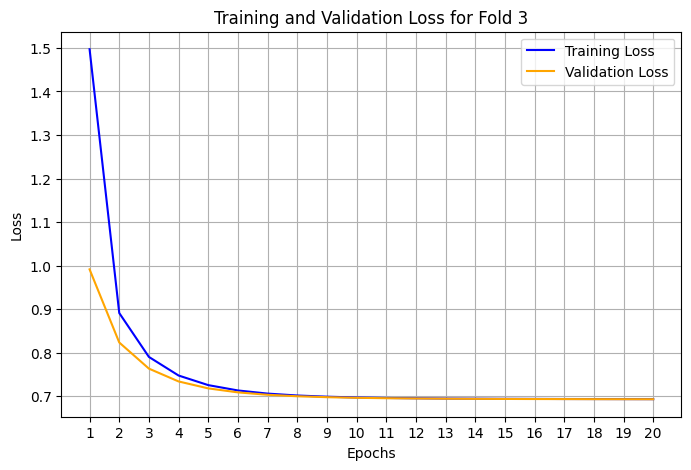

Training on fold 4/5...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.4856 - loss: 1.9321 - val_accuracy: 0.5170 - val_loss: 0.9147 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4997 - loss: 0.8590 - val_accuracy: 0.5170 - val_loss: 0.7619 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5032 - loss: 0.7488 - val_accuracy: 0.5170 - val_loss: 0.7216 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5098 - loss: 0.7171 - val_accuracy: 0.5170 - val_loss: 0.7071 - learning_rate: 0.0010
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5032 - loss: 0.7054 - val_accuracy: 0.5170 - val_loss: 0.7010 - learning_rate: 0.0010
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5050 - loss: 0.7002 - val_accuracy: 0.5170 - val_loss: 0.6980 - learning_rate: 0.0010
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4993 

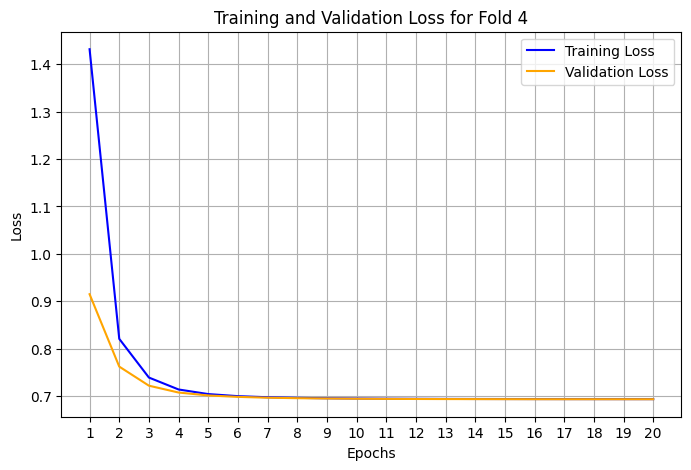

Training on fold 5/5...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.4883 - loss: 1.7723 - val_accuracy: 0.4870 - val_loss: 0.7916 - learning_rate: 0.0010
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5187 - loss: 0.7561 - val_accuracy: 0.4870 - val_loss: 0.7093 - learning_rate: 0.0010
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5146 - loss: 0.7047 - val_accuracy: 0.4870 - val_loss: 0.6984 - learning_rate: 0.0010
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5151 - loss: 0.6967 - val_accuracy: 0.4870 - val_loss: 0.6958 - learning_rate: 0.0010
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5123 - loss: 0.6945 - val_accuracy: 0.4870 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4960 - loss: 0.6941 - val_accuracy: 0.4870 - val_loss: 0.6942 - learning_rate: 0.0010
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5101 

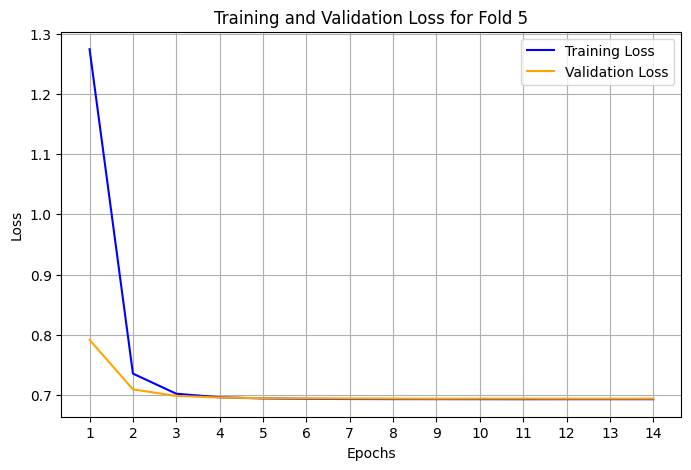

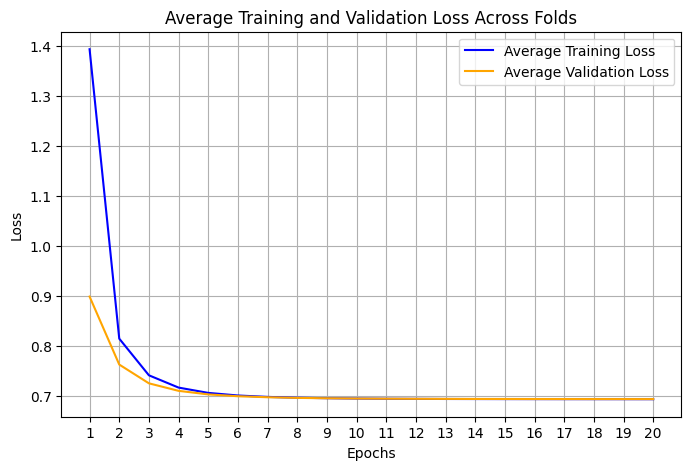

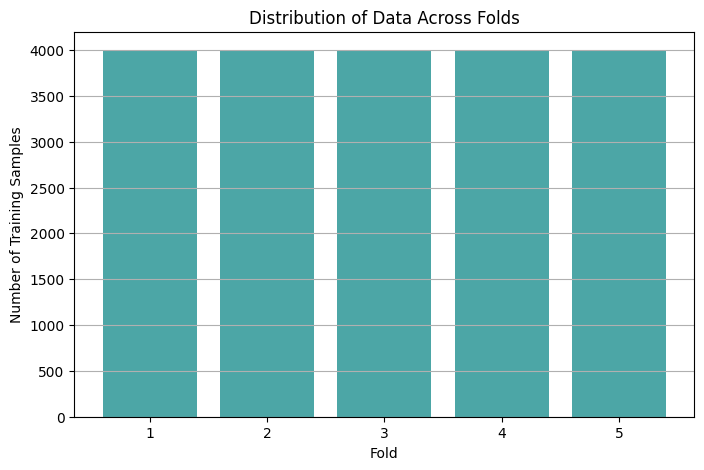

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5001 - loss: 0.6934
Test Loss: 0.6938295364379883, Test Accuracy: 0.4869999885559082


In [34]:
# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# Step 2: Load and Prepare Data
# Replace with your data loading logic
combined_images = np.random.rand(5000, 128, 128)  # Replace with actual images
combined_labels = np.random.randint(0, 2, size=5000)  # Replace with actual labels

# Expand dimensions for grayscale images to match CNN input
combined_images = combined_images.reshape(-1, 128, 128, 1)

# Step 3: Create a CNN Model for Classification with Best Hyperparameters
def create_cnn_model(input_shape=(128, 128, 1)):
    model = Sequential([
        Conv2D(16, (3, 3), activation='relu', kernel_regularizer=l2(0.01), input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
        MaxPooling2D((2, 2)),
        Conv2D(96, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Step 4: K-Fold Cross-Validation
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)
folds_history = []
avg_train_loss = []
avg_val_loss = []

for fold, (train_index, val_index) in enumerate(kf.split(combined_images)):
    print(f"Training on fold {fold + 1}/{k}...")

    X_train, X_val = combined_images[train_index], combined_images[val_index]
    y_train, y_val = combined_labels[train_index], combined_labels[val_index]

    # Instantiate and compile the model
    cnn_model = create_cnn_model()

    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

    # Train the model
    history = cnn_model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr]
    )

    # Store history
    folds_history.append(history)
    
    # Track average loss
    avg_train_loss.append(history.history['loss'])
    avg_val_loss.append(history.history['val_loss'])

    # Plot for current fold
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title(f'Training and Validation Loss for Fold {fold + 1}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.xticks(ticks=np.arange(0, len(history.history['loss'])), labels=np.arange(1, len(history.history['loss']) + 1))
    plt.show()

# Step 5: Plot Average Loss across Folds
# Calculate average losses by padding each array to the same length (max length of epochs in any fold)
max_epochs = max(len(loss) for loss in avg_train_loss)
avg_train_loss_padded = np.array([np.pad(loss, (0, max_epochs - len(loss)), 'edge') for loss in avg_train_loss])
avg_val_loss_padded = np.array([np.pad(loss, (0, max_epochs - len(loss)), 'edge') for loss in avg_val_loss])

# Compute the mean across the folds
mean_train_loss = np.mean(avg_train_loss_padded, axis=0)
mean_val_loss = np.mean(avg_val_loss_padded, axis=0)

# Plot the average training and validation losses
plt.figure(figsize=(8, 5))
plt.plot(mean_train_loss, label='Average Training Loss', color='blue')
plt.plot(mean_val_loss, label='Average Validation Loss', color='orange')
plt.title('Average Training and Validation Loss Across Folds')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.xticks(ticks=np.arange(0, max_epochs), labels=np.arange(1, max_epochs + 1))
plt.show()

# Step 6: Plot Data Distribution Across Folds
fold_sizes = [len(train_index) for train_index, _ in kf.split(combined_images)]
plt.figure(figsize=(8, 5))
plt.bar(range(1, k + 1), fold_sizes, color='teal', alpha=0.7)
plt.title('Distribution of Data Across Folds')
plt.xlabel('Fold')
plt.ylabel('Number of Training Samples')
plt.xticks(range(1, k + 1))
plt.grid(axis='y')
plt.show()

# Step 7: Evaluate the Model on the Last Fold
final_fold = k - 1
loss, accuracy = folds_history[final_fold].model.evaluate(X_val, y_val)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')
